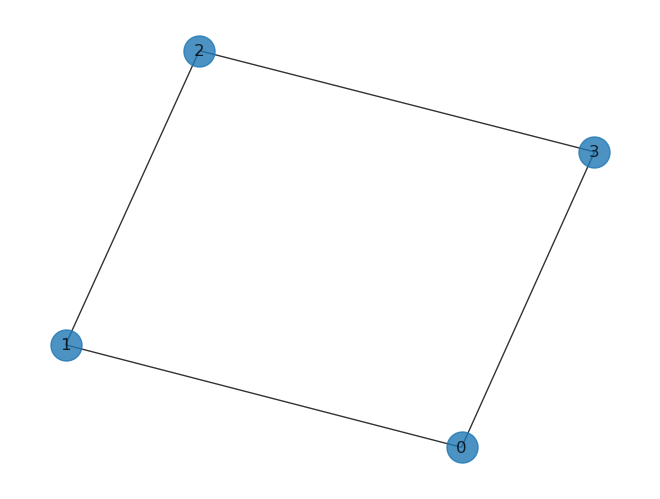

In [55]:
import networkx as nx
graph = nx.Graph()
graph.add_nodes_from([0, 1, 2, 3])
graph.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 0)])
nx.draw(graph, with_labels=True, alpha=0.8, node_size=500)

In [57]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.circuit import Parameter  # Create symbolic parameters for variational circuits

In [59]:
def maxcut_obj(solution, graph):
    """Given a bit string as a solution, this function returns
    the number of edges shared between the two partitions
    of the graph.
    Args:
        solution: (str) solution bit string
        graph: networkx graph
    Returns:
        obj: (float) Objective
    """
    obj = 0
    for i, j in graph.edges():
        if solution[i] != solution[j]:
            obj -= 1
    return obj

In [61]:
def compute_expectation(counts, graph):
    """Computes expectation value based on measurement results
    Args:
        counts: (dict) key as bit string, val as count
        graph: networkx graph
    Returns:
        avg: float
             expectation value
    """
    avg = 0
    sum_count = 0
    for bit_string, count in counts.items():
        obj = maxcut_obj(bit_string, graph)
        avg += obj * count
        sum_count += count
    return avg/sum_count

In [63]:
def create_qaoa_circuit(graph, parms, draw_layers=False):
    """Creates a parametrized qaoa circuit
    Args:
        graph: networkx graph
        parms: (list) unitary parameters
    Returns:
        (QuantumCircuit) qiskit circuit
    """
    nqubits = len(graph.nodes())
    n_layers = len(parms)//2  # number of alternating unitaries
    beta = parms[:n_layers]
    gamma = parms[n_layers:]

    qc = QuantumCircuit(nqubits)

    # initial_state
    qc.h(range(nqubits))

    for layer_index in range(n_layers):
        # cost unitary
        for pair in list(graph.edges()):
            qc.rzz(2 * gamma[layer_index], pair[0], pair[1])

            
        # mixer unitary
        for qubit in range(nqubits):
            qc.rx(2 * beta[layer_index], qubit)
        
            
    qc.measure_all()

    if draw_layers:
        print("Full Circuit")
        display(qc.draw('mpl'))
    return qc


In [65]:
# write a function that executes the circuit on the chosen backend
def get_expectation(graph, shots=512):
    """Runs parametrized circuit
    Args:
        graph: networkx graph
    """
    backend = Aer.get_backend('qasm_simulator')
    backend.shots = shots

    def execute_circ(theta):
        qc = create_qaoa_circuit(graph, theta)
        counts = backend.run(qc, seed_simulator=10,
                             nshots=512).result().get_counts()
        return compute_expectation(counts, graph)

    return execute_circ

In [67]:
from scipy.optimize import minimize
expectation = get_expectation(graph)
res = minimize(expectation,
               [1,  1],
               method='COBYLA')
res

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -2.994140625
       x: [ 1.979e+00  1.167e+00]
    nfev: 30
   maxcv: 0.0

Full Circuit


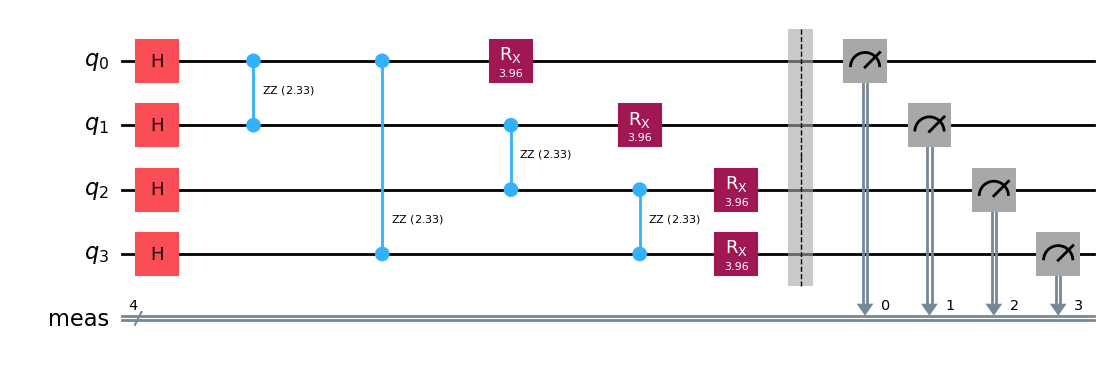

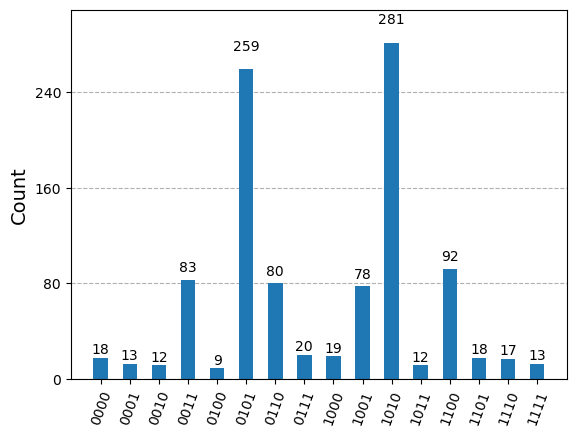

In [69]:
backend = Aer.get_backend('aer_simulator')
parms_opt = res.x
qc_final = create_qaoa_circuit(graph, parms_opt, draw_layers=True)
backend.shots = 512

from qiskit.visualization import plot_histogram
qc_res = create_qaoa_circuit(graph, res.x)
counts = backend.run(qc_res, seed_simulator=10).result().get_counts()
plot_histogram(counts)